In [49]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [2]:
california = fetch_california_housing()

In [8]:
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

In [9]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [11]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [25]:
X = df[['MedInc']]
y = df['PRICE']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [27]:
model = LinearRegression()

In [28]:
model.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = model.predict(X_test)

In [30]:
y_pred

array([1.14958917, 1.50606882, 1.90393718, ..., 4.31500772, 1.612455  ,
       1.93412956])

In [38]:
X_train.head()

,MedInc
14196,3.2596
8267,3.8125
17445,4.1563
14265,1.9425
2271,3.5542


In [39]:
y_train.head()

,PRICE
14196,1.030
8267,3.821
17445,1.726
14265,0.934
2271,0.965


In [40]:
X_test.head()

,MedInc
20046,1.6812
3024,2.5313
15663,3.4801
20484,5.7376
9814,3.7250


In [41]:
y_test.head()

,PRICE
20046,0.47700
3024,0.45800
15663,5.00001
20484,2.18600
9814,2.78000


In [46]:
custom_medinc = float(input("Enter a custom 'MedInc' value (e.g., 5.0 for $50,000 median income): "))
custom_input_df = pd.DataFrame({'MedInc': [custom_medinc]})
custom_prediction = model.predict(custom_input_df)
print(f"For a median income (MedInc) of {custom_medinc}, the predicted house price is: ${custom_prediction[0]:.2f}")

Enter a custom 'MedInc' value (e.g., 5.0 for $50,000 median income): 3.4801
For a median income (MedInc) of 3.4801, the predicted house price is: $1.90


In [47]:
# Model parameters
print(f"\n=== MODEL RESULTS ===")
print(f"Intercept (β₀): {model.intercept_:.4f}")
print(f"Slope (β₁): {model.coef_[0]:.4f}")
print(f"Regression Equation: Price = {model.intercept_:.4f} + {model.coef_[0]:.4f} × MedInc")



=== MODEL RESULTS ===
Intercept (β₀): 0.4446
Slope (β₁): 0.4193
Regression Equation: Price = 0.4446 + 0.4193 × MedInc


In [50]:
# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n=== PERFORMANCE METRICS ===")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")



=== PERFORMANCE METRICS ===
R² Score: 0.4589
Mean Squared Error: 0.7091
Root Mean Squared Error: 0.8421
Mean Absolute Error: 0.6299


In [51]:
# Interpretation
print(f"\n=== INTERPRETATION ===")
print(f"For each $10,000 increase in median income, house price increases by ${model.coef_[0]*100000:.2f}")
print(f"The model explains {r2*100:.2f}% of the variance in house prices")


=== INTERPRETATION ===
For each $10,000 increase in median income, house price increases by $41933.85
The model explains 45.89% of the variance in house prices


In [52]:
import matplotlib.pyplot as plt

In [53]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

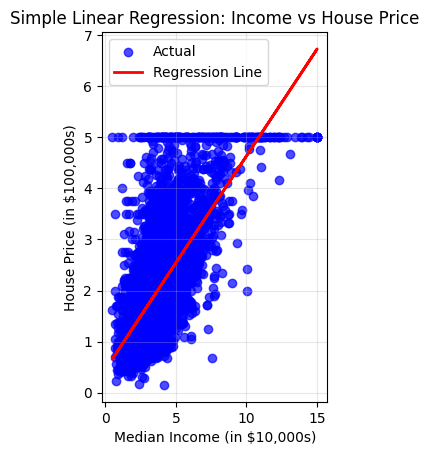

In [54]:
plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, alpha=0.7, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Median Income (in $10,000s)')
plt.ylabel('House Price (in $100,000s)')
plt.title('Simple Linear Regression: Income vs House Price')
plt.legend()
plt.grid(True, alpha=0.3)

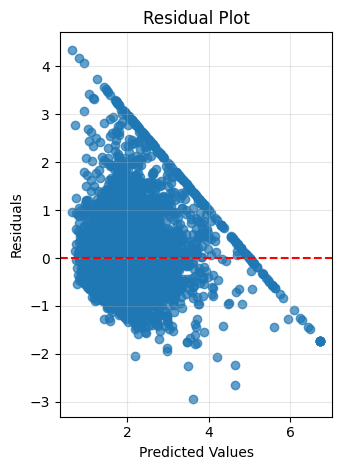

In [56]:
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
new_incomes = np.array([[3.0], [6.0], [9.0]])  # $30k, $60k, $90k
predicted_prices = model.predict(new_incomes)

print(f"\n=== SAMPLE PREDICTIONS ===")
for income, price in zip(new_incomes, predicted_prices):
    print(f"Median Income: ${income[0]*10000:.0f} → Predicted Price: ${price*100000:.2f}")


=== SAMPLE PREDICTIONS ===
Median Income: $30000 → Predicted Price: $170261.28
Median Income: $60000 → Predicted Price: $296062.83
Median Income: $90000 → Predicted Price: $421864.37


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
